# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [2]:
#Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.dummy import DummyClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [3]:
!git clone https://github.com/anthonyfeaster/UCB-AIML.git
%cd /content/UCB-AIML/Practical-3
!ls
!ls data

Cloning into 'UCB-AIML'...
remote: Enumerating objects: 230, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 230 (delta 23), reused 0 (delta 0), pack-reused 192 (from 1)
Receiving objects: 100% (230/230), 13.53 MiB | 4.36 MiB/s, done.
Resolving deltas: 100% (102/102), done.
Updating files: 100% (17/17), done.
/content/UCB-AIML/Practical-3
data  prompt_III.ipynb	README.md
bank-additional.csv  bank-additional-full.csv  bank-additional-names.txt


### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [4]:
#Creating a dataframe from the csv
bank = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [5]:
bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [6]:
#Printing the Datatypes
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [7]:
bank.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [8]:
#Printing Number of Rows and Columns plus Column Names
print(f'Rows: {bank.shape[0]}, Columns: {bank.shape[1]}')
print(f"Column Names: {bank.columns.tolist()}")

Rows: 41188, Columns: 21
Column Names: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


In [9]:
#Looking for Missing Values
bank.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [10]:
# Checking for Duplicate Values
print(f"Number of Duplicate Values: {bank.duplicated().sum()}")

Number of Duplicate Values: 12


In [11]:
#Dropping Duplicate Values
bank = bank.drop_duplicates()

#Validating that the duplicated rows were dropped
print(f"Number of Duplicate Values: {bank.duplicated().sum()}")

Number of Duplicate Values: 0


Checked dataset for duplicate rows. Found 12 values and deleted them.

In [12]:
#Looking at the unique values for the y column
bank['y'].value_counts()

,count
y,
no,36537
yes,4639


In [13]:
#Looking at the unique values for the job column
bank['job'].value_counts()

,count
job,
admin.,10419
blue-collar,9253
technician,6739
services,3967
management,2924
retired,1718
entrepreneur,1456
self-employed,1421
housemaid,1060


In [14]:
#Looking at the unique values for the default column
bank['default'].value_counts()

,count
default,
no,32577
unknown,8596
yes,3


In [15]:
#Find all of the unknown values
unknown_values = bank.isin(['unknown']).sum()

#Creating new DataFrame to display the number of unknown entries and percentage for each column
unknown_summary = pd.DataFrame({
    'Count': unknown_values,
    'Percentage': (unknown_values / len(bank) * 100).round(2).astype(str) + '%'
})

unknown_summary = unknown_summary[unknown_summary['Count'] > 0]

unknown_summary


,Count,Percentage
job,330,0.8%
marital,80,0.19%
education,1730,4.2%
default,8596,20.88%
housing,990,2.4%
loan,990,2.4%


In [16]:
#Dropping unknown rows in the job  & marital column since its only .8%  & .19% of the entries
bank = bank[bank['job'] != 'unknown']
bank = bank[bank['marital'] != 'unknown']

#Validate that 'unknown' entries were removed from the job and marital columns
print(f" Number of 'unknown' entries in the Job column: {bank['job'].isin(['unknown']).sum()}")
print(f" Number of 'unknown' entries in the Marital column: {bank['marital'].isin(['unknown']).sum()}")


 Number of 'unknown' entries in the Job column: 0
 Number of 'unknown' entries in the Marital column: 0


I removed the rows in the 'job' and 'marital' column where the value was 'unknown' because it was only .8% and .19% of the total entries and wont drastically reduce the dataset. I kept 'unknown'in the education, default, housing and loan because it made of 20% of the default data.

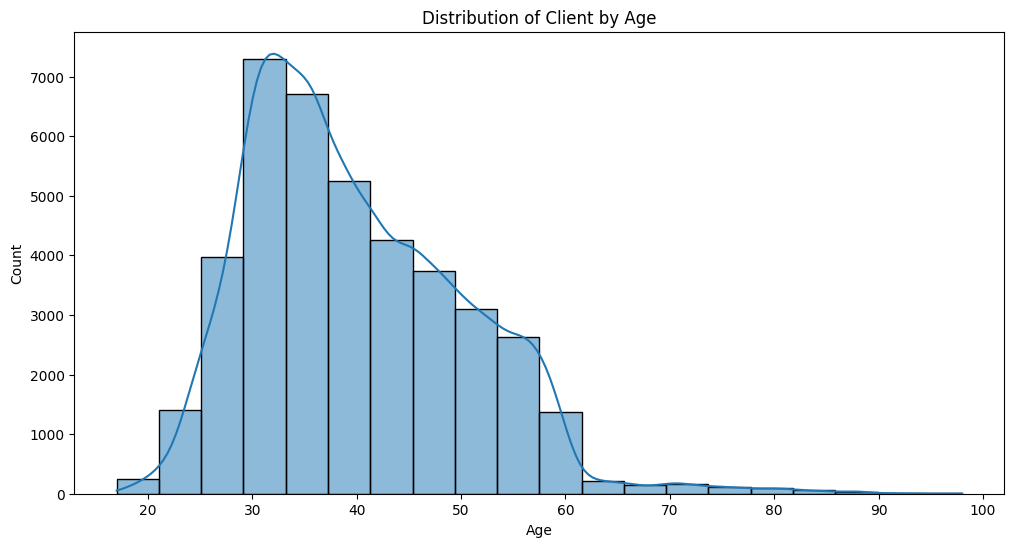

In [17]:
#Creating histogram showcasing the distribution of client by age
plt.figure(figsize=(12, 6))
sns.histplot(bank['age'], bins=20, kde=True)
plt.title('Distribution of Client by Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

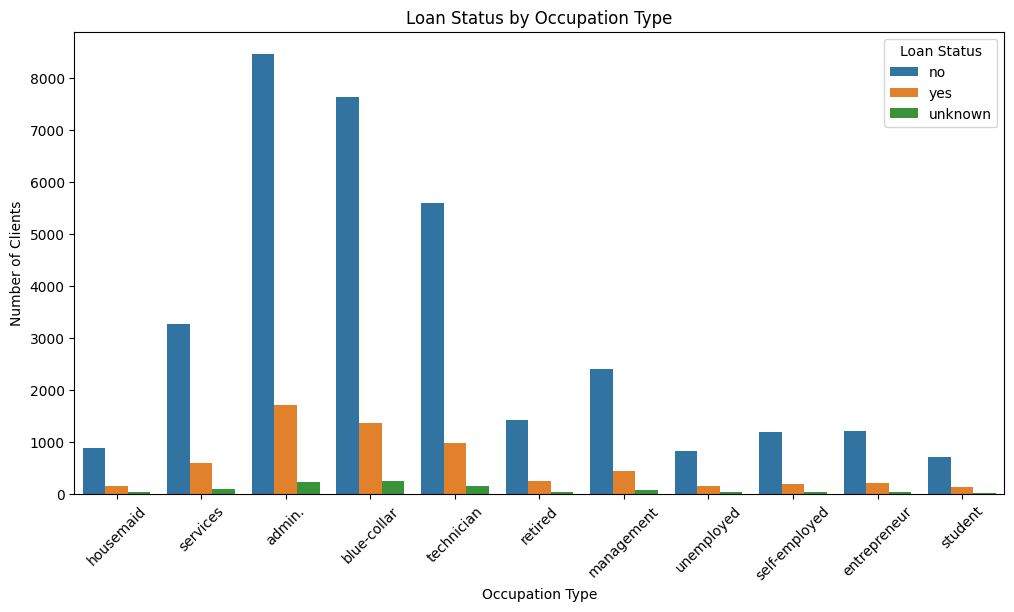

In [18]:
#How many clients have a loan across each job level

plt.figure(figsize=(12, 6))
sns.countplot(data=bank, x='job', hue='loan')
plt.title('Loan Status by Occupation Type')
plt.xlabel('Occupation Type')
plt.ylabel('Number of Clients')
plt.legend(title='Loan Status')
plt.xticks(rotation=45)
plt.show()

This chart compares the loan status accross the various occupation types. Most clients accross the occupation types donot have a loan. Most of the clients who have a loan come from the admin, blue-collar and technician occupation groups.

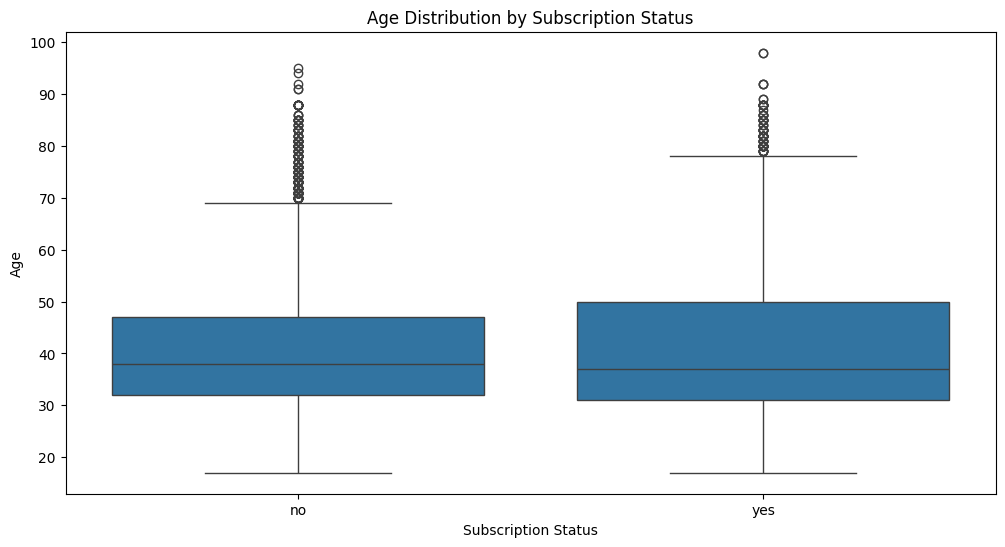

In [19]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=bank, x='y', y='age')
plt.title('Age Distribution by Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Age')
plt.show()

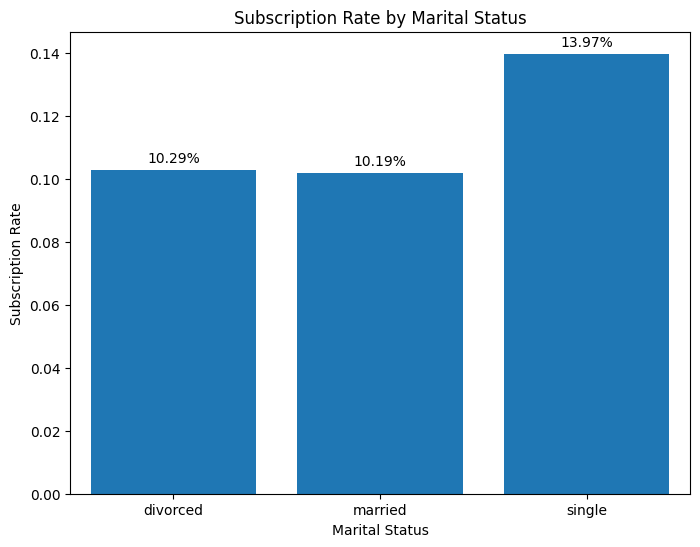

In [20]:
#Calculating the subscription rate of the clients by marital status
marital_sub_rate = bank.groupby('marital')['y'].apply(lambda x: (x == 'yes').mean())

plt.figure(figsize=(8, 6))
marital_sub_rate.plot(kind='bar')

plt.title('Subscription Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Subscription Rate')
plt.xticks(rotation=0)

#Adding percentages to each bar
bars = plt.bar(marital_sub_rate.index, marital_sub_rate.values)
plt.bar_label(bars, labels=[f'{value * 100:.2f}%' for value in marital_sub_rate.values], padding=3)
plt.show()

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

The business objective for this task is to determine whether a client of the bank will subscribe to a term deposit based off of bank information features

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [21]:
#Selecting bank features
bank_features = [
    'age',
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan'
]
X = bank[bank_features]
y = bank['y']

In [22]:

numeric_features = ['age']
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ]
)

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size = 0.2,
  random_state = 42
)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [24]:
baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train, y_train)
baseline_prediction = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_prediction)
baseline_balanced_accuracy = balanced_accuracy_score(y_test, baseline_prediction)
print(f"Baseline Accuracy: {baseline_accuracy}")
print(f"Baseline Balanced Accuracy: {baseline_balanced_accuracy * 100:.2f}%")

Baseline Accuracy: 0.8844880441446965
Baseline Balanced Accuracy: 50.00%


In [37]:
majority_class = y_train.value_counts(normalize=True).idxmax()

print(f'Majority Class: {majority_class}')



Majority Class: no


DummyClassifier was selected to create a baseline model utilizing the most frequent strategy. This model predicts using the majority class. The purpose of a baseline model is to provide a benchmark score for machine learning models to beat.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [25]:
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression())
])

#Capturing how long the model takes to fit
lr_start_time = time.time()
lr_model.fit(X_train, y_train)
lr_fit_time = time.time() - lr_start_time

### Problem 9: Score the Model

What is the accuracy of your model?

In [26]:
lr_train_model = lr_model.score(X_train, y_train)
lr_test_model = lr_model.score(X_test, y_test)
lr_prediction = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_prediction)

print(f"Accuracy Score: {lr_accuracy}")

Accuracy Score: 0.8844880441446965


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [27]:
knn_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

#Capturing how long the model takes to fit
knn_start_time = time.time()
knn_model.fit(X_train, y_train)
knn_fit_time = time.time() - knn_start_time

knn_prediction = knn_model.predict(X_test)
knn_train_accuracy = knn_model.score(X_train, y_train)
knn_test_accuracy = knn_model.score(X_test, y_test)

print(f"KNN Accuracy Score: {knn_test_accuracy}")

KNN Accuracy Score: 0.8719803801348865


In [28]:
dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier())
])

#Capturing how long the model takes to fit
dt_start_time = time.time()
dt_model.fit(X_train, y_train)
dt_fit_time = time.time() - dt_start_time

dt_prediction = dt_model.predict(X_test)
dt_train_accuracy = dt_model.score(X_train, y_train)
dt_test_accuracy = dt_model.score(X_test, y_test)

print(f"Decision Tree Accuracy Score: {dt_test_accuracy}")

Decision Tree Accuracy Score: 0.8659717964438994


In [29]:
svm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC())
])
#Capturing how long the model takes to fit
svm_start_time = time.time()
svm_model.fit(X_train, y_train)
svm_fit_time = time.time() - svm_start_time

svm_prediction = svm_model.predict(X_test)
svm_train_accuracy = svm_model.score(X_train, y_train)
svm_test_accuracy = svm_model.score(X_test, y_test)

print(f"SVM Accuracy Score: {svm_test_accuracy}")

SVM Accuracy Score: 0.8849785407725322


In [30]:
model_comparison = pd.DataFrame({
    'Model': ['lr_model', 'knn_model', 'dt_model', 'svm_model'],
    'Train Time': [lr_fit_time, knn_fit_time, dt_fit_time, svm_fit_time],
    'Train Accuracy': [lr_train_model, knn_train_accuracy, dt_train_accuracy, svm_train_accuracy],
    'Test Accuracy': [lr_test_model, knn_test_accuracy, dt_test_accuracy, svm_test_accuracy]
})

print(model_comparison)

       Model  Train Time  Train Accuracy  Test Accuracy
0   lr_model    0.409223        0.888075       0.884488
1  knn_model    0.310269        0.892857       0.871980
2   dt_model    0.756001        0.916646       0.865972
3  svm_model  113.011520        0.888443       0.884979


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [31]:
dt_params = {
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 5, 10]
}

In [32]:
dt_grid = GridSearchCV(
    estimator=dt_model,
    param_grid=dt_params,
    scoring='accuracy',
    cv=5
)
dt_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age']),
                                                                        ('cat',
                                                                         OneHotEncoder(),
                                                                         ['job',
                                                                          'marital',
                                                                          'education',
                                                                          'default',
                                                                          'housing',
                                                                          'loan'])])),
                                       ('model', DecisionTreeClassifier())]),
             param_grid={'model__max_depth': [None, 10, 20, 30],
                         'model__min_samples_leaf': [1, 5, 10],
                         'model__min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [33]:
dt_grid.best_params_



{'model__max_depth': 10,
 'model__min_samples_leaf': 10,
 'model__min_samples_split': 5}

In [34]:
dt_best_train_accuracy = dt_grid.score(X_train, y_train)
dt_best_test_accuracy = dt_grid.score(X_test, y_test)

print(f'Improved Decision Tree Train Accuracy: {dt_best_train_accuracy}')
print(f'Improved Decision Tree Test Accuracy: {dt_best_test_accuracy}')

Improved Decision Tree Train Accuracy: 0.8909871244635194
Improved Decision Tree Test Accuracy: 0.882158185162477


In [35]:
dt_improvement = pd.DataFrame({
    'Model': ['Original Decision Tree', 'Improved Decision Tree'],
    'Train Accuracy': [dt_train_accuracy, dt_best_train_accuracy],
    'Test Accuracy': [dt_test_accuracy, dt_best_test_accuracy]
})

print(dt_improvement)

                    Model  Train Accuracy  Test Accuracy
0  Original Decision Tree        0.916646       0.865972
1  Improved Decision Tree        0.890987       0.882158


##### Questions